# Spectra demo

Demonstrates the `ocpy.spectra` package: the lightweight `Spectrum` and
`SpectrumStack` classes, source adapters for PANAGEA / Loisel+2023, and
xarray / netCDF interop.

Generated by JXP and Claude.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ocpy.spectra import Spectrum, SpectrumStack
from ocpy.spectra import io as spectra_io

## 1. A PANAGEA Rrs spectrum

`from_panagea` pulls the wavelength/value from `panagea.spectrum`, the units
from the column metadata, and the date/lat/lon/depth from the row.

In [2]:
from ocpy.insitu import panagea

df = panagea.load('rrs')
obs_id = df.index[0]
rrs = spectra_io.from_panagea(df, obs_id, kind='rrs')
rrs

<Spectrum n=6 411.0-665.0 nm units=1/sr source=PANAGEA>

wavelengths: [411. 443. 489. 510. 555. 665.]
units: 1/sr | source: PANAGEA
lat/lon: -64.815 -64.041 | date: 1997-01-02T12:48:00.000000


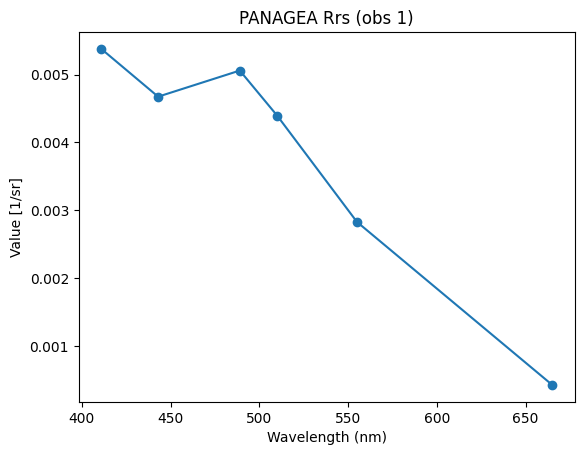

In [3]:
print('wavelengths:', rrs.wavelength)
print('units:', rrs.units, '| source:', rrs.source)
print('lat/lon:', rrs.lat, rrs.lon, '| date:', rrs.date)

ax = rrs.plot(marker='o')
ax.set_title(f'PANAGEA Rrs (obs {obs_id})')
plt.show()

## 2. A Loisel+2023 Hydrolight spectrum

The Loisel+2023 files share one `Lambda` grid and carry no unit metadata, so
we pass the known convention (`Rrs` is in 1/sr) explicitly.

In [4]:
from ocpy.hydrolight import loisel23

ds = loisel23.load_ds(1, 0)
rrs_l23 = spectra_io.from_loisel23(ds, 0, var='Rrs', units='1/sr')
rrs_l23

<Spectrum n=81 350.0-750.0 nm units=1/sr source=Loisel2023>

## 3. Rebin both onto a common grid

`Spectrum.rebin` delegates to the array-level helpers in
`ocpy.spectra.utils` and carries the provenance over.

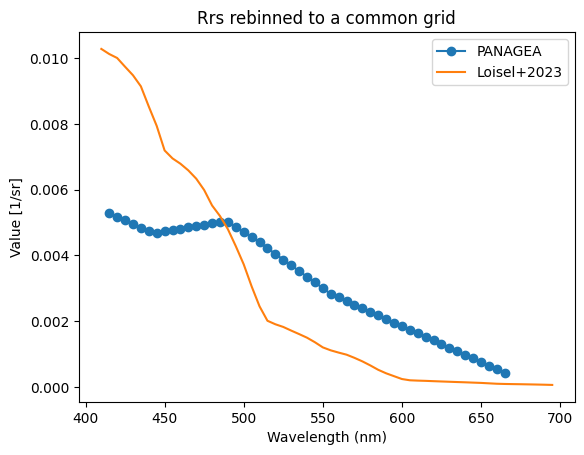

In [5]:
wv_grid = np.arange(410., 700., 5.)
rrs_rb = rrs.rebin(wv_grid)
rrs_l23_rb = rrs_l23.rebin(wv_grid)

fig, ax = plt.subplots()
rrs_rb.plot(ax=ax, marker='o', label='PANAGEA')
rrs_l23_rb.plot(ax=ax, label='Loisel+2023')
ax.legend()
ax.set_title('Rrs rebinned to a common grid')
plt.show()

## 4. Build a SpectrumStack

Once on a shared grid, a stack exposes a 2D `(nspec, nwave)` view via
`as_array()`.

In [6]:
stack = SpectrumStack([rrs_rb, rrs_l23_rb])
print('len:', len(stack), '| gridded:', stack.is_gridded)
wv, values, errors = stack.as_array()
print('values shape (nspec, nwave):', values.shape)
print('sources:', list(stack.sources))

len: 2 | gridded: True
values shape (nspec, nwave): (2, 58)
sources: ['PANAGEA', 'Loisel2023']


<SpectrumStack n=50 gridded> | gridded: True


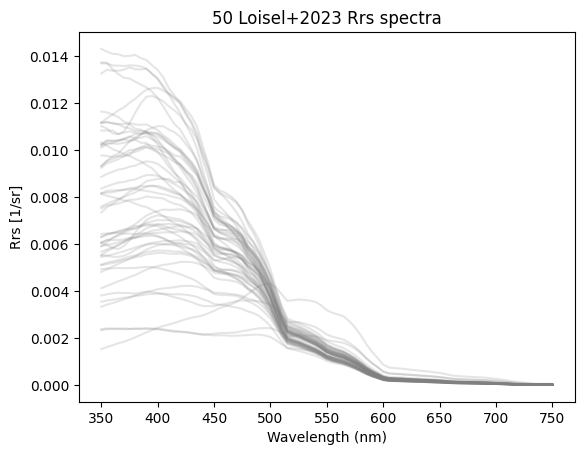

In [7]:
# A larger gridded stack straight from Loisel+2023.
l23_stack = spectra_io.stack_from_loisel23(
    ds, var='Rrs', indices=range(50), units='1/sr')
print(repr(l23_stack), '| gridded:', l23_stack.is_gridded)

wv, vals, _ = l23_stack.as_array()
fig, ax = plt.subplots()
ax.plot(wv, vals.T, color='gray', alpha=0.2)
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Rrs [1/sr]')
ax.set_title('50 Loisel+2023 Rrs spectra')
plt.show()

## 5. xarray and netCDF round trips

In the xarray form, **wavelength is a data variable**, not a coordinate.

In [8]:
xds = rrs.to_xarray()
xds

<xarray.Dataset> Size: 144B
Dimensions:     (channel: 6)
Dimensions without coordinates: channel
Data variables:
    wavelength  (channel) float64 48B 411.0 443.0 489.0 510.0 555.0 665.0
    values      (channel) float64 48B 0.005377 0.004674 ... 0.002831 0.0004322
    errors      (channel) float64 48B nan nan nan nan nan nan
Attributes:
    has_errors:     0
    units:          1/sr
    source:         PANAGEA
    date:           1997-01-02T12:48:00.000000
    lat:            -64.815
    lon:            -64.041
    depth:          423.0
    metadata_json:  {"dataset": "nomad", "subdataset": "nomad_palmer_lter", "...

In [9]:
print('wavelength in data_vars:', 'wavelength' in xds.data_vars)
print('wavelength in coords:', 'wavelength' in xds.coords)

back = Spectrum.from_xarray(xds)
print('round-trip values match:', np.allclose(back.values, rrs.values))

wavelength in data_vars: True
wavelength in coords: False
round-trip values match: True


In [10]:
import tempfile, os

with tempfile.TemporaryDirectory() as tmp:
    path = os.path.join(tmp, 'rrs.nc')
    rrs.to_netcdf(path)
    rrs2 = Spectrum.read_netcdf(path)
print('netCDF round-trip source:', rrs2.source, '| n:', len(rrs2))

netCDF round-trip source: PANAGEA | n: 6
